<a href="https://colab.research.google.com/github/vaishnavikale404/DataScienceLab_64/blob/main/practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv


Dataset Preview:
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    1008

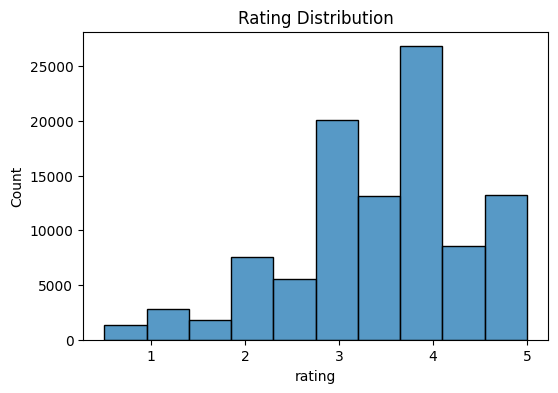


Classification Accuracy: 0.6574276080920269

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.51      0.54      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168



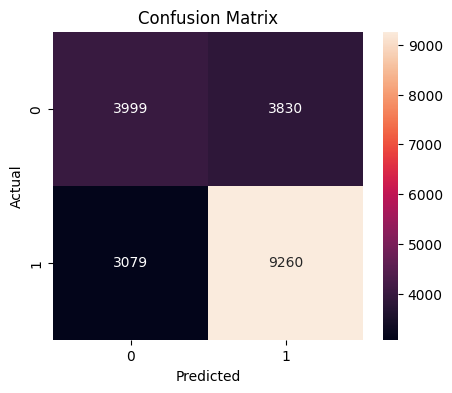

In [24]:
# 🔹 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix

# 🔹 2. Load Dataset
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Merge datasets
data = pd.merge(ratings, movies, on="movieId")

# 🔹 3. Preview Data
print("Dataset Preview:")
print(data.head())

print("\nDataset Info:")
print(data.info())

# 🔹 4. Preprocessing
# Convert genres to numeric
data['genres'] = data['genres'].astype('category').cat.codes

# Features and target (Regression)
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

# 🔹 5. Train-Test Split (Regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# 🔹 6. Train Regression Model
reg = RandomForestRegressor()
reg.fit(X_train, y_train)

# 🔹 7. Prediction (Regression)
y_pred = reg.predict(X_test)

# 🔹 8. Evaluate Regression
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nRegression RMSE:", rmse)

# 🔹 9. Visualization - Rating Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

# 🔹 10. Convert to Classification
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

# Features and target (Classification)
y_cls = data['rating_class']

# 🔹 11. Train-Test Split (Classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

# 🔹 12. Train Classification Model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# 🔹 13. Prediction (Classification)
y_pred_cls = clf.predict(X_test)

# 🔹 14. Evaluate Classification
print("\nClassification Accuracy:", accuracy_score(y_test, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cls))

# 🔹 15. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cls)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()